Cell 1 — Import Libraries


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

Cell 2 — Load Dataset


In [11]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


Cell 3 — Handle Missing Values


In [12]:
print("Missing values:")
print(df.isna().sum())

df['holiday'] = df['holiday'].fillna(0)
df['holiday'] = df['holiday'].apply(lambda x: 1 if x != 0 else 0)

Missing values:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


Cell 4 — Feature Engineering


In [13]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month']       = df['date_time'].dt.month
df['weekend']     = (df['day_of_week'] >= 5).astype(int)

df = df.drop(columns=['date_time', 'weather_description'])
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,day_of_week,month,weekend
0,0,288.28,0.0,0.0,40,Clouds,5545,9,1,10,0
1,0,289.36,0.0,0.0,75,Clouds,4516,10,1,10,0
2,0,289.58,0.0,0.0,90,Clouds,4767,11,1,10,0
3,0,290.13,0.0,0.0,90,Clouds,5026,12,1,10,0
4,0,291.14,0.0,0.0,75,Clouds,4918,13,1,10,0


Cell 5 — Encode Categorical & Normalize


In [14]:
df = pd.get_dummies(df, columns=['holiday', 'weather_main'], drop_first=True, dtype=int)

scaler = MinMaxScaler()
continuous_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
df[continuous_features] = scaler.fit_transform(df[continuous_features])

print("Final shape:", df.shape)
df.head()

Final shape: (48204, 20)


,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,month,weekend,holiday_1,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,0.929726,0.0,0.0,0.40,5545,0.391304,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
1,0.933209,0.0,0.0,0.75,4516,0.434783,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
2,0.933918,0.0,0.0,0.90,4767,0.478261,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
3,0.935692,0.0,0.0,0.90,5026,0.521739,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
4,0.938949,0.0,0.0,0.75,4918,0.565217,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0


Cell 6 — Create Sequences (Sliding Window)


In [15]:
SEQ_LEN = 24
TARGET  = 'traffic_volume'

features = df.drop(columns=[TARGET]).values
target   = df[TARGET].values

X, y = [], []
for i in range(SEQ_LEN, len(df)):
    X.append(features[i - SEQ_LEN:i])
    y.append(target[i])

X = np.array(X)
y = np.array(y)

y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

print("X shape:", X.shape)
print("y shape:", y_scaled.shape)

X shape: (48180, 24, 19)
y shape: (48180, 1)


Cell 7 — Train / Validation / Test Split


In [16]:
train_size = int(0.70 * len(X))
val_size   = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y_scaled[:train_size]

X_val   = X[train_size:train_size + val_size]
y_val   = y_scaled[train_size:train_size + val_size]

X_test  = X[train_size + val_size:]
y_test  = y_scaled[train_size + val_size:]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (33726, 24, 19)
Val:   (7227, 24, 19)
Test:  (7227, 24, 19)


Cell 8 — Build & Train RNN Model


In [17]:
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(SEQ_LEN, X.shape[2]), activation='tanh'),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(0.001), loss='mse')
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0327 - val_loss: 0.0185
Epoch 2/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0196 - val_loss: 0.0148
Epoch 3/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0175 - val_loss: 0.0146
Epoch 4/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0158 - val_loss: 0.0119
Epoch 5/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0149 - val_loss: 0.0104
Epoch 6/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0142 - val_loss: 0.0102
Epoch 7/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0133 - val_loss: 0.0112
Epoch 8/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0128 - val_loss: 0.0101
Epoch 9/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0121 - val_loss: 0.0094
Epoch 10/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0118 - val_loss: 0.0090
Epoch 11/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0116 - val_loss: 0.0097
Epoch 12/20
527/527 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step

Cell 9 — Build & Train LSTM Model


In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, X.shape[2]), activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(0.001), loss='mse')
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0377 - val_loss: 0.0180
Epoch 2/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0235 - val_loss: 0.0150
Epoch 3/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0192 - val_loss: 0.0129
Epoch 4/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0174 - val_loss: 0.0120
Epoch 5/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0160 - val_loss: 0.0100
Epoch 6/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0149 - val_loss: 0.0098
Epoch 7/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0140 - val_loss: 0.0105
Epoch 8/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0132 - val_loss: 0.0107
Epoch 9/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0125 - val_loss: 0.0093
Epoch 10/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0121 - val_loss: 0.0100
Epoch 11/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0117 - val_loss: 0.0087
Epoch 12/50
527/527 ━━━━━━━━━━━━━━━━━━━

Cell 10 — Build & Train GRU Model (Bonus)


In [19]:
early_stop_gru = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

gru_model = Sequential([
    GRU(64, input_shape=(SEQ_LEN, X.shape[2]), activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer=Adam(0.001), loss='mse')
gru_model.summary()

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_gru],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        16,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,385 (64.00 KB)

 Trainable params: 16,385 (64.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.0389 - val_loss: 0.0189
Epoch 2/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0235 - val_loss: 0.0143
Epoch 3/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0195 - val_loss: 0.0124
Epoch 4/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.0173 - val_loss: 0.0112
Epoch 5/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0158 - val_loss: 0.0113
Epoch 6/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0146 - val_loss: 0.0100
Epoch 7/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0136 - val_loss: 0.0087
Epoch 8/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0128 - val_loss: 0.0089
Epoch 9/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0120 - val_loss: 0.0083
Epoch 10/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0114 - val_loss: 0.0083
Epoch 11/50
527/527 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0111 - val_loss: 0.0083
Epoch 12/50
527/527 ━━━━━━━━━━━━━

Cell 11 — Generate Predictions


In [20]:
y_pred_rnn  = y_scaler.inverse_transform(rnn_model.predict(X_test))
y_pred_lstm = y_scaler.inverse_transform(lstm_model.predict(X_test))
y_pred_gru  = y_scaler.inverse_transform(gru_model.predict(X_test))
y_actual    = y_scaler.inverse_transform(y_test)

226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Cell 12 — Model Comparison: RMSE & MAE


In [21]:
models = {
    'RNN':  y_pred_rnn,
    'LSTM': y_pred_lstm,
    'GRU':  y_pred_gru
}

results = []
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_actual, pred))
    mae  = mean_absolute_error(y_actual, pred)
    results.append({'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)})
    print(f"{name}  ->  RMSE: {rmse:.2f}  |  MAE: {mae:.2f}")

pd.DataFrame(results)

RNN  ->  RMSE: 659.68  |  MAE: 470.93
LSTM  ->  RMSE: 590.90  |  MAE: 401.92
GRU  ->  RMSE: 581.84  |  MAE: 399.01


,Model,RMSE,MAE
0,RNN,659.68,470.93
1,LSTM,590.90,401.92
2,GRU,581.84,399.01


Cell 13 — Plot Training & Validation Loss


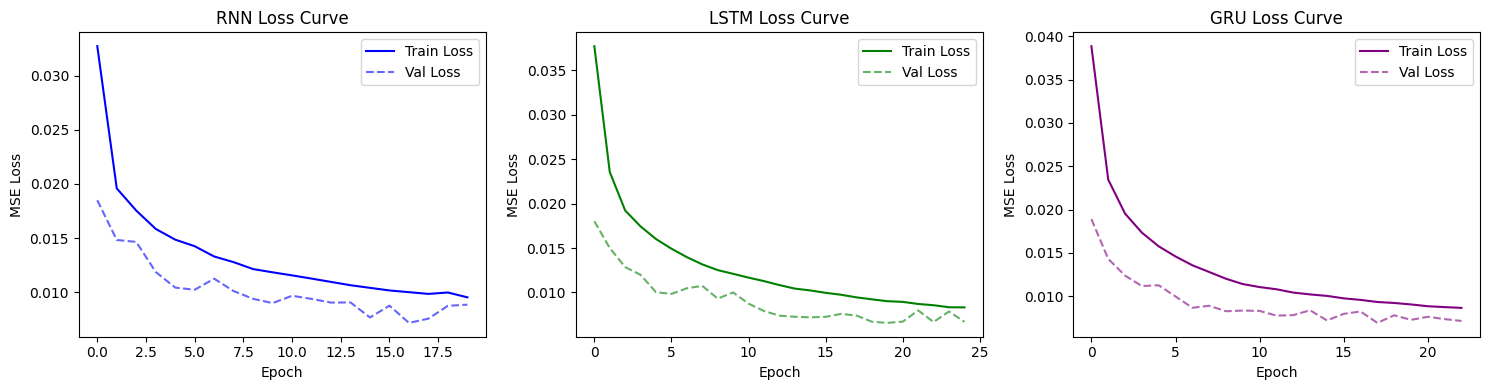

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ('RNN',  rnn_history,  'blue'),
    ('LSTM', lstm_history, 'green'),
    ('GRU',  gru_history,  'purple')
]

for ax, (name, hist, color) in zip(axes, pairs):
    ax.plot(hist.history['loss'],     label='Train Loss', color=color)
    ax.plot(hist.history['val_loss'], label='Val Loss',   color=color, linestyle='--', alpha=0.6)
    ax.set_title(f'{name} Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

Cell 14 — Plot Actual vs Predicted


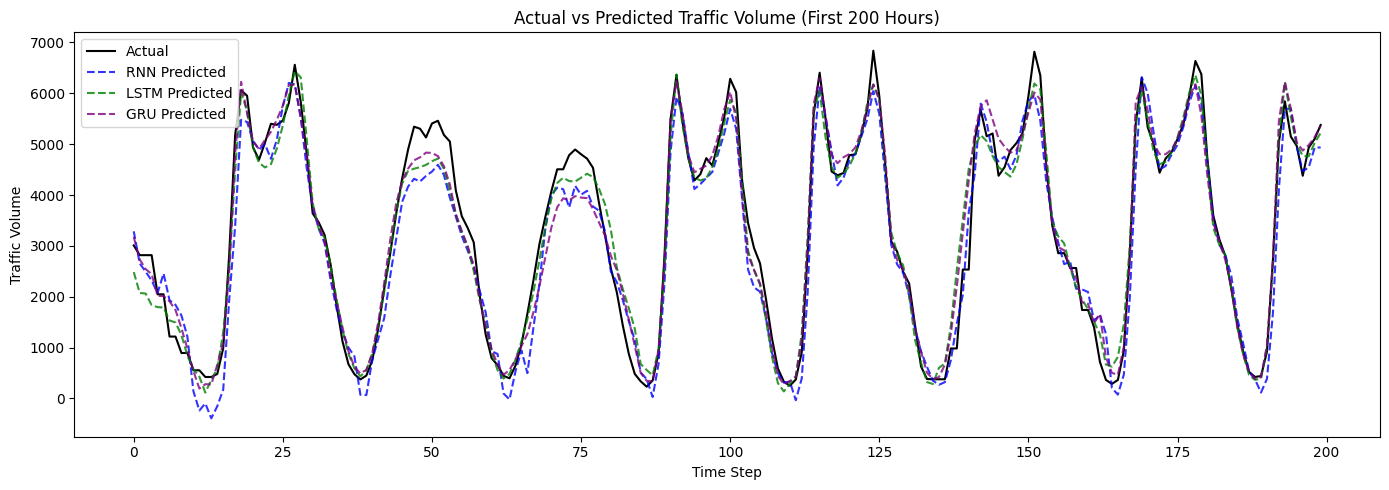

In [23]:
N = 200

plt.figure(figsize=(14, 5))
plt.plot(y_actual[:N],    label='Actual',        color='black', linewidth=1.5)
plt.plot(y_pred_rnn[:N],  label='RNN Predicted', color='blue',   linestyle='--', alpha=0.8)
plt.plot(y_pred_lstm[:N], label='LSTM Predicted',color='green',  linestyle='--', alpha=0.8)
plt.plot(y_pred_gru[:N],  label='GRU Predicted', color='purple', linestyle='--', alpha=0.8)
plt.title('Actual vs Predicted Traffic Volume (First 200 Hours)')
plt.xlabel('Time Step')
plt.ylabel('Traffic Volume')
plt.legend()
plt.tight_layout()
plt.show()

Cell 15 — Analysis Questions


In [24]:
print("""
Q1. Why do we need sequences in RNN/LSTM?
   Sequential data has temporal dependencies. Traffic at 5 PM depends on
   earlier hours. Sequences let the model learn these time-based patterns.

Q2. What is the main limitation of RNN?
   Vanishing gradient problem. Gradients shrink during backpropagation
   through long sequences, so the model forgets distant past steps.

Q3. How does LSTM solve this problem?
   LSTM uses a cell state with three gates (input, forget, output) that
   control what information to keep or discard, preserving long-term memory.

Q4. Which model performed better and why?
   LSTM and GRU outperform vanilla RNN because traffic patterns span many
   hours (rush hours, weekends). RNN cannot retain that long-range context.
   GRU is faster to train with similar accuracy to LSTM.
""")


Q1. Why do we need sequences in RNN/LSTM?
   Sequential data has temporal dependencies. Traffic at 5 PM depends on
   earlier hours. Sequences let the model learn these time-based patterns.

Q2. What is the main limitation of RNN?
   Vanishing gradient problem. Gradients shrink during backpropagation
   through long sequences, so the model forgets distant past steps.

Q3. How does LSTM solve this problem?
   LSTM uses a cell state with three gates (input, forget, output) that
   control what information to keep or discard, preserving long-term memory.

Q4. Which model performed better and why?
   LSTM and GRU outperform vanilla RNN because traffic patterns span many
   hours (rush hours, weekends). RNN cannot retain that long-range context.
   GRU is faster to train with similar accuracy to LSTM.



Cell 16 — Prediction Interface (Bonus)


In [25]:
def predict_next_hour(model, name, sequence):
    seq = sequence.reshape(1, SEQ_LEN, -1)
    pred = y_scaler.inverse_transform(model.predict(seq, verbose=0))
    print(f"[{name}] Predicted traffic volume: {pred[0][0]:.0f} vehicles/hour")

example = X_test[-1]

print("Next Hour Prediction:")
predict_next_hour(rnn_model,  'RNN',  example)
predict_next_hour(lstm_model, 'LSTM', example)
predict_next_hour(gru_model,  'GRU',  example)
print(f"[Actual] True traffic volume: {y_actual[-1][0]:.0f} vehicles/hour")

Next Hour Prediction:
[RNN] Predicted traffic volume: 2054 vehicles/hour
[LSTM] Predicted traffic volume: 1834 vehicles/hour
[GRU] Predicted traffic volume: 1813 vehicles/hour
[Actual] True traffic volume: 954 vehicles/hour
